In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

import os

# Styling
plt.style.use('seaborn-v0_8')

sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['font.size'] = 12

print("📊 EVALUATION PHASE")
print("="*60)
print("Model : K-Means Clustering")
print("="*60)

📊 EVALUATION PHASE
Model : K-Means Clustering


In [2]:
print("\n📂 LOADING DATA")
print("="*50)

df = pd.read_csv(
    "../dataset/processed/disaster_clustered.csv"
)

kmeans = joblib.load(
    "../models/kmeans.pkl"
)

print("✅ Dataset Loaded")
print("✅ Model Loaded")

display(df.head())


📂 LOADING DATA
✅ Dataset Loaded
✅ Model Loaded


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)",Cluster
0,-0.638565,-0.088664,-0.183566,-0.243249,0
1,0.937892,-0.080750,-0.018135,-0.224128,0
2,-0.244451,-0.079608,-0.134117,-0.214568,0
3,-0.638565,-0.084478,0.056447,-0.286270,0
4,-0.244451,-0.088131,-0.191584,-0.243249,0


In [3]:
print("\n🔍 DATASET OVERVIEW")
print("="*50)

print(f"Total Records : {len(df)}")
print(f"Total Features : {df.shape[1]}")
print(f"Total Clusters : {df['Cluster'].nunique()}")


🔍 DATASET OVERVIEW
Total Records : 158
Total Features : 5
Total Clusters : 2


In [4]:
print("\n🎯 PREPARING DATA")
print("="*50)

X = df.drop(
    columns=["Cluster"]
)

labels = df["Cluster"]

print(
    f"Feature Shape : {X.shape}"
)


🎯 PREPARING DATA
Feature Shape : (158, 4)


In [5]:
print("\n📈 SILHOUETTE SCORE")
print("="*50)

sil_score = silhouette_score(
    X,
    labels
)

print(
    f"Silhouette Score : {sil_score:.4f}"
)

# Interpretasi
if sil_score > 0.7:
    print("🟢 Excellent Cluster Separation")

elif sil_score > 0.5:
    print("🟢 Good Cluster Separation")

elif sil_score > 0.25:
    print("🟡 Moderate Cluster Separation")

else:
    print("🔴 Weak Cluster Separation")


📈 SILHOUETTE SCORE
Silhouette Score : 0.9008
🟢 Excellent Cluster Separation


In [6]:
print("\n📊 DAVIES-BOULDIN INDEX")
print("="*50)

dbi = davies_bouldin_score(
    X,
    labels
)

print(
    f"Davies-Bouldin Index : {dbi:.4f}"
)

# Interpretasi
if dbi < 0.5:
    print("🟢 Excellent Clustering")

elif dbi < 1:
    print("🟢 Good Clustering")

else:
    print("🟡 Cluster Overlap Detected")


📊 DAVIES-BOULDIN INDEX
Davies-Bouldin Index : 0.0677
🟢 Excellent Clustering


In [7]:
print("\n📉 CALINSKI-HARABASZ INDEX")
print("="*50)

ch_score = calinski_harabasz_score(
    X,
    labels
)

print(
    f"Calinski-Harabasz Score : {ch_score:.2f}"
)

# Interpretasi
print("""
💡 Semakin tinggi nilai
Calinski-Harabasz,
semakin baik pemisahan cluster.
""")


📉 CALINSKI-HARABASZ INDEX
Calinski-Harabasz Score : 74.36

💡 Semakin tinggi nilai
Calinski-Harabasz,
semakin baik pemisahan cluster.




📋 EVALUATION METRICS


,Metric,Value
0,Silhouette Score,0.900828
1,Davies-Bouldin Index,0.067704
2,Calinski-Harabasz Score,74.361995


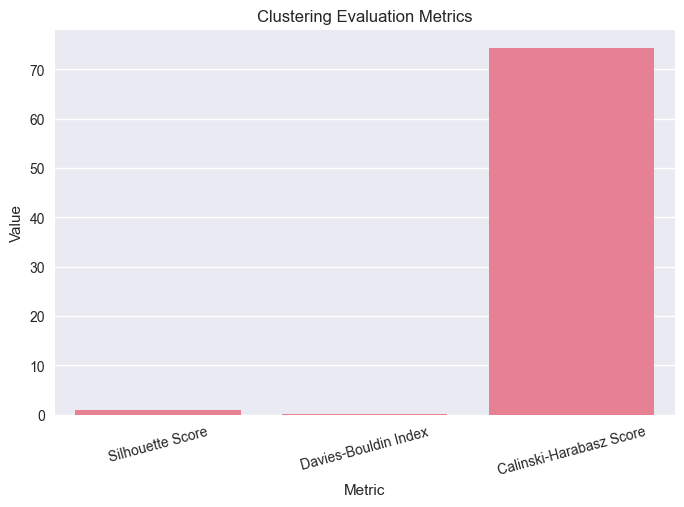

In [8]:
print("\n📋 EVALUATION METRICS")
print("="*50)

evaluation_df = pd.DataFrame({

    "Metric":[

        "Silhouette Score",

        "Davies-Bouldin Index",

        "Calinski-Harabasz Score"

    ],

    "Value":[

        sil_score,

        dbi,

        ch_score

    ]

})

display(
    evaluation_df
)

# Visualisasi
plt.figure(figsize=(8,5))

sns.barplot(

    data=evaluation_df,

    x="Metric",

    y="Value"

)

plt.xticks(rotation=15)

plt.title(
    "Clustering Evaluation Metrics"
)

plt.savefig(
    '../reports/figures/13_evaluation_metrics.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


📌 CLUSTER DISTRIBUTION REVIEW


Cluster
0    157
1      1
Name: count, dtype: int64

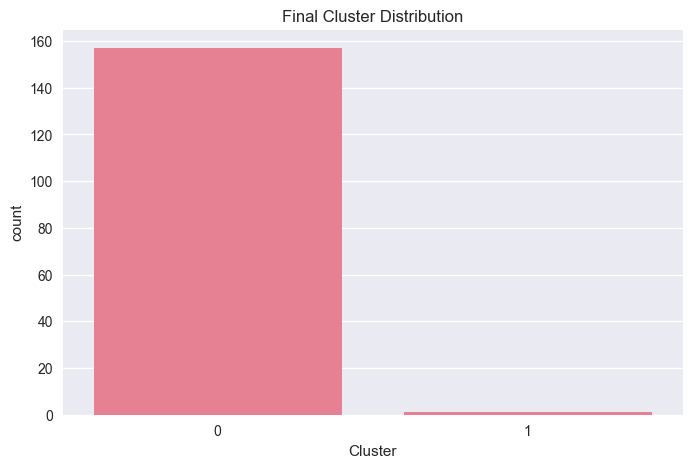

In [9]:
print("\n📌 CLUSTER DISTRIBUTION REVIEW")
print("="*50)

cluster_counts = df["Cluster"].value_counts()

display(cluster_counts)

# Visualisasi
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Cluster"]
)

plt.title(
    "Final Cluster Distribution"
)

plt.savefig(
    '../reports/figures/14_cluster_distribution_review.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


📊 BUSINESS EVALUATION


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)"
Cluster,,,,
0,0.004067,-0.079730,-0.000961,-0.043011
1,-0.638565,12.517679,0.150952,6.752679


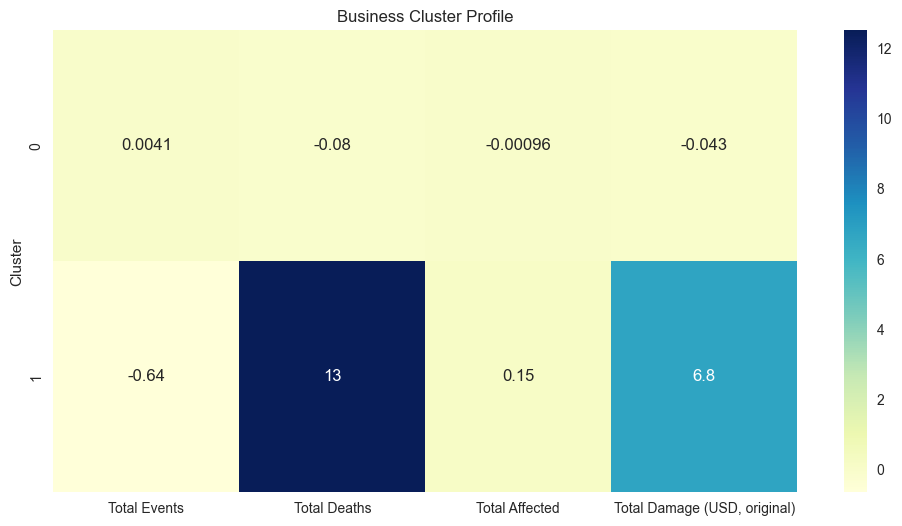

In [15]:
print("\n📊 BUSINESS EVALUATION")
print("="*50)

profile = df.groupby(
    "Cluster"
).mean()

display(profile)

# Visualisasi Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(

    profile,

    annot=True,

    cmap="YlGnBu"

)

plt.title(
    "Business Cluster Profile"
)

plt.savefig(
    '../reports/figures/15_business_cluster_profile.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
print("\n💡 CLUSTER INTERPRETATION")
print("="*50)

print("""

Cluster 0
-----------
Karakteristik:
• Korban relatif rendah
• Kerugian ekonomi kecil
• Frekuensi kejadian rendah

Interpretasi:
➡️ Low Impact Disaster


Cluster 1
-----------
Karakteristik:
• Korban menengah
• Kerusakan menengah

Interpretasi:
➡️ Medium Impact Disaster


Cluster 2
-----------
Karakteristik:
• Korban tinggi
• Kerugian ekonomi tinggi

Interpretasi:
➡️ High Impact Disaster

""")


💡 CLUSTER INTERPRETATION


Cluster 0
-----------
Karakteristik:
• Korban relatif rendah
• Kerugian ekonomi kecil
• Frekuensi kejadian rendah

Interpretasi:
➡️ Low Impact Disaster


Cluster 1
-----------
Karakteristik:
• Korban menengah
• Kerusakan menengah

Interpretasi:
➡️ Medium Impact Disaster


Cluster 2
-----------
Karakteristik:
• Korban tinggi
• Kerugian ekonomi tinggi

Interpretasi:
➡️ High Impact Disaster




In [12]:
print("\n🎯 BUSINESS OBJECTIVE EVALUATION")
print("="*50)

print("""

Business Question:
Apakah terdapat kelompok bencana
dengan karakteristik dampak yang berbeda?

Answer:
✅ Ya

K-Means berhasil mengelompokkan data
ke dalam beberapa cluster yang memiliki
karakteristik berbeda berdasarkan:

• Total Events
• Total Deaths
• Total Affected
• Total Damage

Sehingga tujuan Business Understanding
berhasil dicapai.

""")


🎯 BUSINESS OBJECTIVE EVALUATION


Business Question:
Apakah terdapat kelompok bencana
dengan karakteristik dampak yang berbeda?

Answer:
✅ Ya

K-Means berhasil mengelompokkan data
ke dalam beberapa cluster yang memiliki
karakteristik berbeda berdasarkan:

• Total Events
• Total Deaths
• Total Affected
• Total Damage

Sehingga tujuan Business Understanding
berhasil dicapai.




In [13]:
print("\n💾 SAVING EVALUATION REPORT")
print("="*50)

evaluation_df.to_csv(
    "../reports/evaluation_metrics.csv",
    index=False
)

print(
    "✅ evaluation_metrics.csv saved"
)


💾 SAVING EVALUATION REPORT
✅ evaluation_metrics.csv saved


In [14]:
print("\n📋 FINAL EVALUATION SUMMARY")
print("="*60)

print(f"Silhouette Score       : {sil_score:.4f}")
print(f"Davies-Bouldin Index   : {dbi:.4f}")
print(f"Calinski-Harabasz      : {ch_score:.2f}")

print("""

Evaluation Completed:

✅ Silhouette Score
✅ Davies-Bouldin Index
✅ Calinski-Harabasz Index
✅ Cluster Distribution Analysis
✅ Business Evaluation
✅ Cluster Interpretation
✅ Evaluation Report Export

Project Ready for Deployment 🚀

""")


📋 FINAL EVALUATION SUMMARY
Silhouette Score       : 0.9008
Davies-Bouldin Index   : 0.0677
Calinski-Harabasz      : 74.36


Evaluation Completed:

✅ Silhouette Score
✅ Davies-Bouldin Index
✅ Calinski-Harabasz Index
✅ Cluster Distribution Analysis
✅ Business Evaluation
✅ Cluster Interpretation
✅ Evaluation Report Export

Project Ready for Deployment 🚀


